<a href="https://colab.research.google.com/github/SonaSargs1an/generative-ai-project/blob/main/GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧠 ԱՐԱԳ MRI BRAIN TUMOR DETECTION

📥 Ներբեռնում dataset...
🔧 Մշակում պատկերներ...
✓ Բեռնված: 253 պատկեր
  Tumor: 155, Healthy: 98


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🚀 2D CNN (Simple)
✓ Ավարտված 108.4վ
  Accuracy: 78.4%
  Dice: 0.457
  IoU: 0.296

🚀 2D CNN (Advanced)
✓ Ավարտված 148.4վ
  Accuracy: 45.1%
  Dice: 0.464
  IoU: 0.303

🚀 Pseudo-3D (Simple)
✓ Ավարտված 81.6վ
  Accuracy: 60.8%
  Dice: 0.428
  IoU: 0.273

🚀 Pseudo-3D (Advanced)
✓ Ավարտված 64.3վ
  Accuracy: 60.8%
  Dice: 0.433
  IoU: 0.276

📊 ՎԵՐՋՆԱԿԱՆ ԱՐԴՅՈՒՆՔՆԵՐ
Մոդել                Acc%     Dice     IoU      Ժամանակ   
------------------------------------------------------------
2D Simple            78.4     0.457    0.296    108.4     վ
2D Advanced          45.1     0.464    0.303    148.4     վ
3D Simple            60.8     0.428    0.273    81.6      վ
3D Advanced          60.8     0.433    0.276    64.3      վ


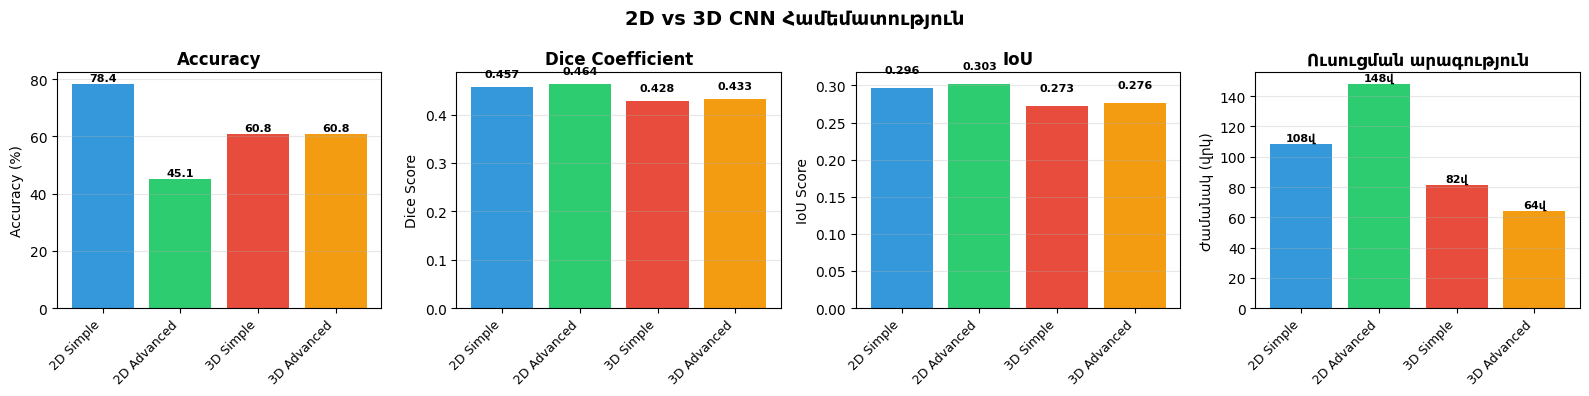

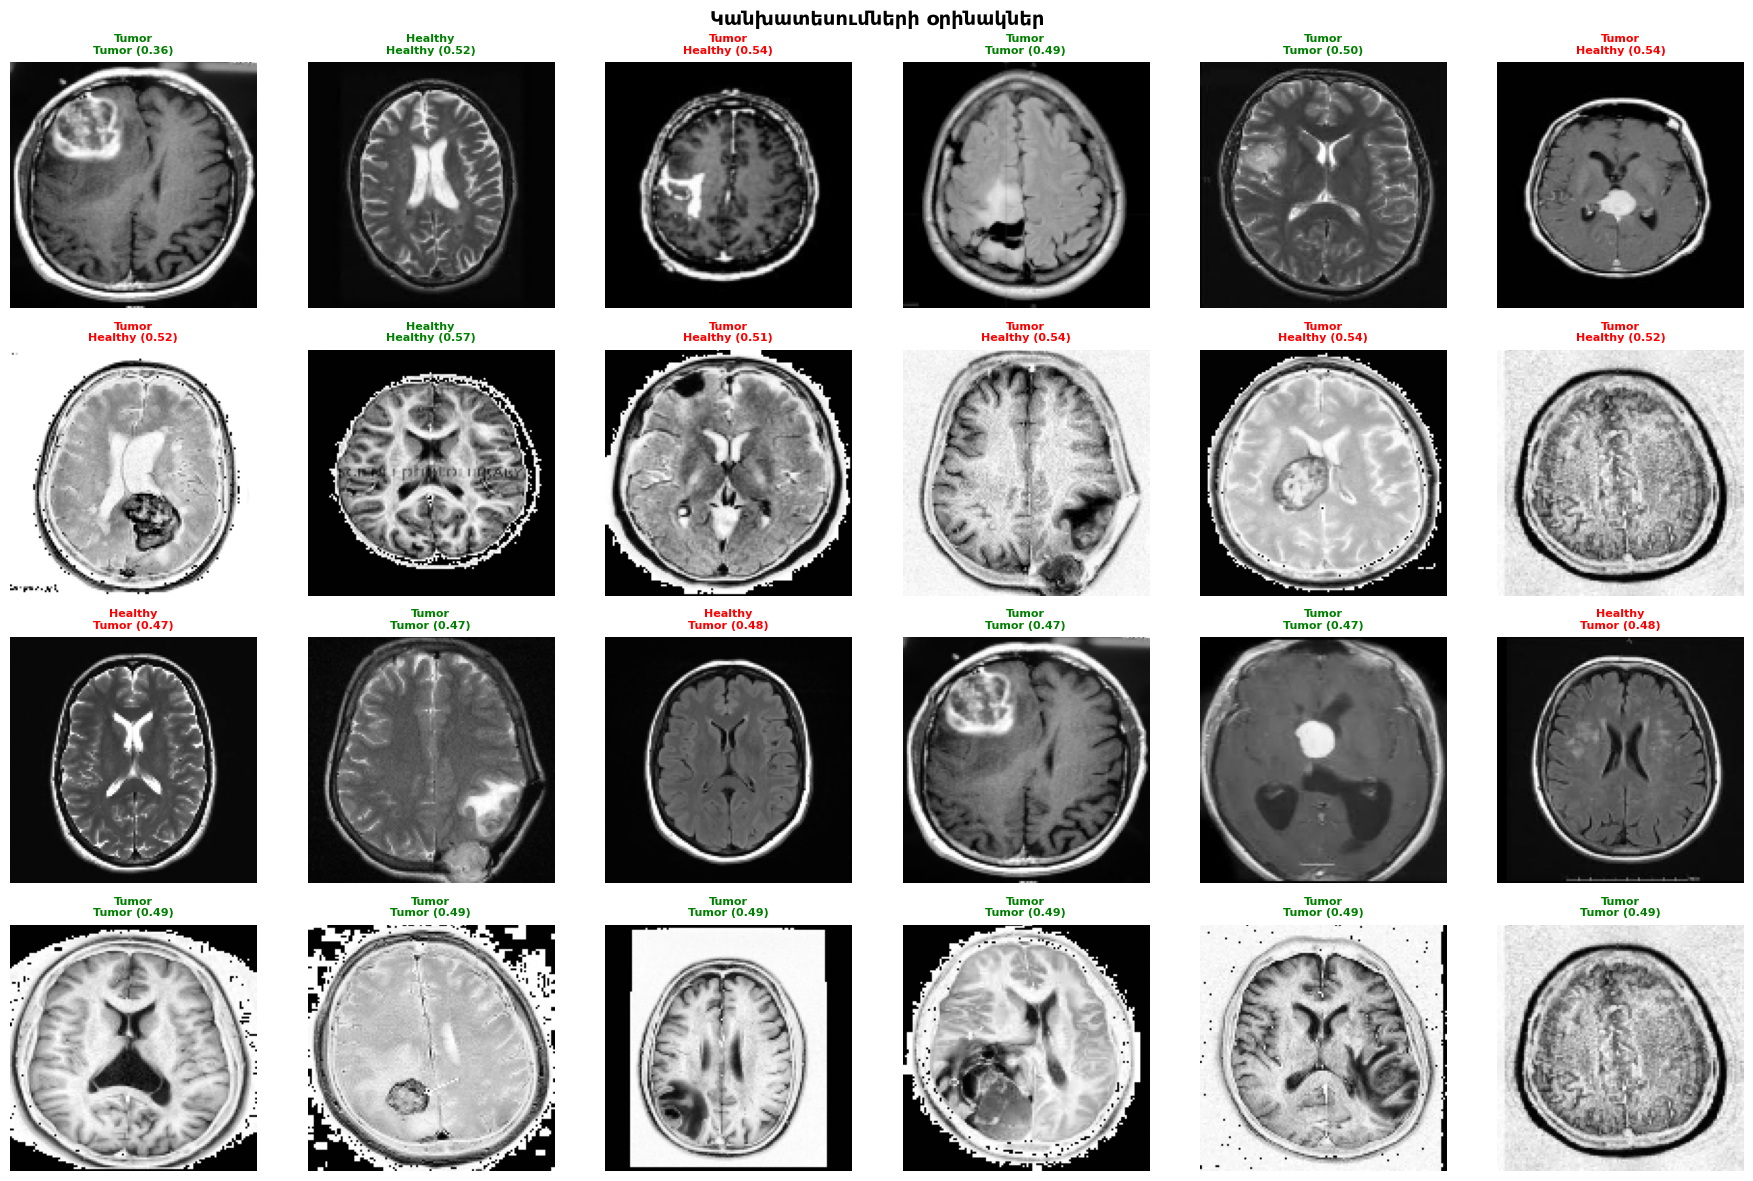

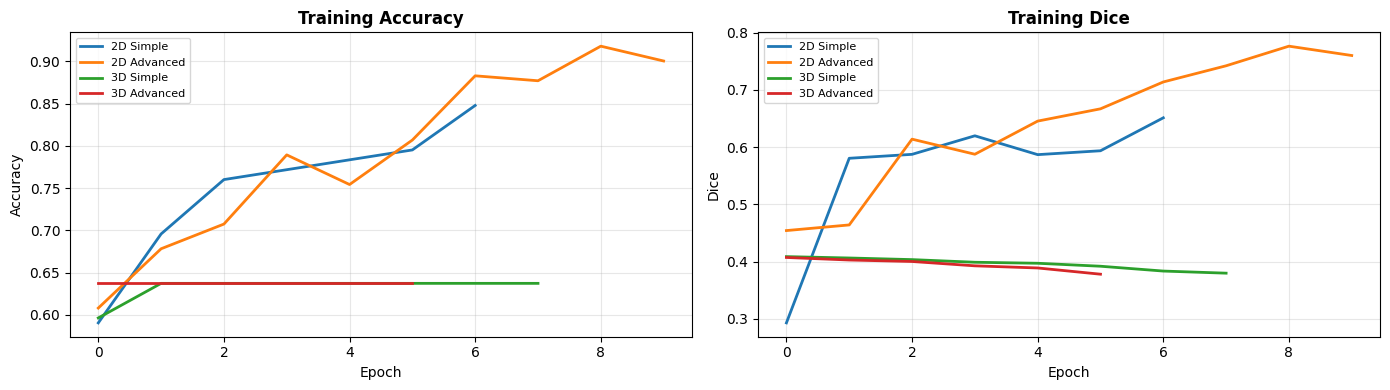


✅ Ավարտված է!


In [ ]:
# ================================================================================
# ԱՐԱԳ & ԱՐԴՅՈՒՆԱՎԵՏ MRI BRAIN TUMOR DETECTION
# 2D vs 3D CNN + Advanced Preprocessing - Օպտիմալացված տարբերակ
# ================================================================================

# --------------------------------------------
# 0) Գրադարաններ
# --------------------------------------------
!pip install tensorflow opencv-python matplotlib scikit-image --quiet

import os, requests, zipfile, io, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from skimage import exposure

# --------------------------------------------
# 1) Սեթափ
# --------------------------------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --------------------------------------------
# 2) Արագ Preprocessing
# --------------------------------------------
class FastPreprocessor:
    """Արագ և արդյունավետ preprocessing"""

    def __init__(self, img_size=128):
        self.img_size = img_size

    def process(self, img):
        # Resize
        img = cv2.resize(img, (self.img_size, self.img_size))
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Simple normalization
        img = img.astype(np.float32) / 255.0
        return img

    def process_advanced(self, img):
        # Resize
        img = cv2.resize(img, (self.img_size, self.img_size))
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # CLAHE
        img_norm = (img * 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img = clahe.apply(img_norm).astype(np.float32) / 255.0

        # Z-score normalization
        mean, std = img.mean(), img.std()
        if std > 0:
            img = (img - mean) / std
            img = np.clip(img, -3, 3)
            img = (img + 3) / 6

        return img

# --------------------------------------------
# 3) Dataset ներբեռնում
# --------------------------------------------
print("="*60)
print("🧠 ԱՐԱԳ MRI BRAIN TUMOR DETECTION")
print("="*60)

url = "https://github.com/MohamedAliHabib/Brain-Tumor-Detection/archive/refs/heads/master.zip"
print("\n📥 Ներբեռնում dataset...")
r = requests.get(url)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("/content")

BASE_DIR = "/content/Brain-Tumor-Detection-master"
IMG_SIZE = 128

# --------------------------------------------
# 4) Բեռնում պատկերներ
# --------------------------------------------
print("🔧 Մշակում պատկերներ...")
prep = FastPreprocessor(IMG_SIZE)

data_simple, data_advanced, labels = [], [], []

for label, cls in enumerate(["yes", "no"]):
    path = os.path.join(BASE_DIR, cls)
    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name))
        if img is None: continue

        data_simple.append(prep.process(img))
        data_advanced.append(prep.process_advanced(img))
        labels.append(label)

data_simple = np.array(data_simple)[..., np.newaxis]
data_advanced = np.array(data_advanced)[..., np.newaxis]
labels = np.array(labels)

print(f"✓ Բեռնված: {len(labels)} պատկեր")
print(f"  Tumor: {sum(labels==0)}, Healthy: {sum(labels==1)}")

# Split
X_tr_s, X_te_s, y_tr, y_te = train_test_split(
    data_simple, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_tr_a, X_te_a, _, _ = train_test_split(
    data_advanced, labels, test_size=0.2, random_state=SEED, stratify=labels
)

# --------------------------------------------
# 5) Մոդելներ
# --------------------------------------------
def build_2d_cnn():
    return models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(IMG_SIZE,IMG_SIZE,1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

def build_pseudo_3d():
    inp = Input((IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.Conv2D(32, 1, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.Conv2D(64, 1, activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    return Model(inp, out)

# --------------------------------------------
# 6) Metrics
# --------------------------------------------
def dice_coef(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(y_pred)
    inter = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2.*inter + 1e-6) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + 1e-6)

def iou_coef(y_true, y_pred):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(y_pred)
    inter = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - inter
    return (inter + 1e-6) / (union + 1e-6)

# --------------------------------------------
# 7) Ուսուցում
# --------------------------------------------
def train_fast(model, X_tr, X_te, y_tr, y_te, name):
    print(f"\n{'='*60}")
    print(f"🚀 {name}")
    print(f"{'='*60}")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', dice_coef, iou_coef]
    )

    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr,
        validation_split=0.15,
        epochs=15,  # Քիչ epochs
        batch_size=32,  # Մեծ batch
        callbacks=[
            EarlyStopping('val_loss', patience=5, restore_best_weights=True),
            ReduceLROnPlateau('val_loss', factor=0.5, patience=3, min_lr=1e-7)
        ],
        verbose=0  # Silent training
    )
    t = time.time() - t0

    res = model.evaluate(X_te, y_te, verbose=0)

    print(f"✓ Ավարտված {t:.1f}վ")
    print(f"  Accuracy: {res[1]*100:.1f}%")
    print(f"  Dice: {res[2]:.3f}")
    print(f"  IoU: {res[3]:.3f}")

    return hist, res, t

# --------------------------------------------
# 8) Ուսուցում բոլոր մոդելները
# --------------------------------------------
results = {}

# 1. 2D Simple
m1 = build_2d_cnn()
h1, r1, t1 = train_fast(m1, X_tr_s, X_te_s, y_tr, y_te, "2D CNN (Simple)")
results['2D Simple'] = (h1, r1, t1, m1, X_te_s)

# 2. 2D Advanced
m2 = build_2d_cnn()
h2, r2, t2 = train_fast(m2, X_tr_a, X_te_a, y_tr, y_te, "2D CNN (Advanced)")
results['2D Advanced'] = (h2, r2, t2, m2, X_te_a)

# 3. Pseudo-3D Simple
m3 = build_pseudo_3d()
h3, r3, t3 = train_fast(m3, X_tr_s, X_te_s, y_tr, y_te, "Pseudo-3D (Simple)")
results['3D Simple'] = (h3, r3, t3, m3, X_te_s)

# 4. Pseudo-3D Advanced
m4 = build_pseudo_3d()
h4, r4, t4 = train_fast(m4, X_tr_a, X_te_a, y_tr, y_te, "Pseudo-3D (Advanced)")
results['3D Advanced'] = (h4, r4, t4, m4, X_te_a)

# --------------------------------------------
# 9) Համեմատություն
# --------------------------------------------
print("\n" + "="*60)
print("📊 ՎԵՐՋՆԱԿԱՆ ԱՐԴՅՈՒՆՔՆԵՐ")
print("="*60)
print(f"{'Մոդել':<20} {'Acc%':<8} {'Dice':<8} {'IoU':<8} {'Ժամանակ':<10}")
print("-"*60)

for name, (_, res, t, _, _) in results.items():
    print(f"{name:<20} {res[1]*100:<8.1f} {res[2]:<8.3f} {res[3]:<8.3f} {t:<10.1f}վ")

# --------------------------------------------
# 10) Վիզուալիզացիա
# --------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

names = list(results.keys())
accs = [results[n][1][1]*100 for n in names]
dices = [results[n][1][2] for n in names]
ious = [results[n][1][3] for n in names]
times = [results[n][2] for n in names]

colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

# Accuracy
axes[0].bar(range(4), accs, color=colors)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accs):
    axes[0].text(i, v+1, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')

# Dice
axes[1].bar(range(4), dices, color=colors)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Dice Coefficient', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(dices):
    axes[1].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# IoU
axes[2].bar(range(4), ious, color=colors)
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[2].set_ylabel('IoU Score')
axes[2].set_title('IoU', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(ious):
    axes[2].text(i, v+0.02, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

# Time
axes[3].bar(range(4), times, color=colors)
axes[3].set_xticks(range(4))
axes[3].set_xticklabels(names, rotation=45, ha='right', fontsize=9)
axes[3].set_ylabel('Ժամանակ (վրկ)')
axes[3].set_title('Ուսուցման արագություն', fontweight='bold')
axes[3].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(times):
    axes[3].text(i, v+2, f'{v:.0f}վ', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('2D vs 3D CNN Համեմատություն', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --------------------------------------------
# 11) Կանխատեսումներ
# --------------------------------------------
fig, axes = plt.subplots(4, 6, figsize=(18, 12))

for row, (name, (_, _, _, model, X_te)) in enumerate(results.items()):
    indices = np.random.choice(len(X_te), 6, replace=False)

    for col, idx in enumerate(indices):
        img = X_te[idx]
        true = y_te[idx]
        pred = model.predict(img.reshape(1,IMG_SIZE,IMG_SIZE,1), verbose=0)[0][0]
        pred_label = 1 if pred > 0.5 else 0

        axes[row, col].imshow(img[:,:,0], cmap='gray')

        true_txt = "Tumor" if true==0 else "Healthy"
        pred_txt = "Tumor" if pred_label==0 else "Healthy"
        color = 'green' if true==pred_label else 'red'

        axes[row, col].set_title(
            f"{true_txt}\n{pred_txt} ({pred:.2f})",
            color=color, fontsize=8, fontweight='bold'
        )
        axes[row, col].axis('off')

    axes[row, 0].set_ylabel(name, fontweight='bold', fontsize=10)

plt.suptitle('Կանխատեսումների օրինակներ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --------------------------------------------
# 12) Training History
# --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, (hist, _, _, _, _) in results.items():
    axes[0].plot(hist.history['accuracy'], label=name, linewidth=2)
    axes[1].plot(hist.history['dice_coef'], label=name, linewidth=2)

axes[0].set_title('Training Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Training Dice', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Ավարտված է!")